In [40]:
import sys
import os

# Add project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from helpers import (load_data, 
                     plot_dataset_split_distribution, 
                     ModelTrainer, 
                     plot_model_performance_subplots, 
                     plot_correct_landmarks, 
                     plot_two_class_table)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import joblib

In [41]:
# datasets splits folder path
datasets_splits_folder_path = "../dataset/splits/v1"

In [42]:
# load label encoder
transformers_path = "../models/transformers"
le = joblib.load(f"{transformers_path}/label_encoder.pkl")

In [43]:
X_train_df, y_train_df, X_dev_df, y_dev_df, X_test_df, y_test_df = load_data(datasets_splits_folder_path)

# check the shapes of the datasets
print("X_train shape:", X_train_df.shape)
print("y_train shape:", y_train_df.shape)
print("X_dev shape:", X_dev_df.shape)
print("y_dev shape:", y_dev_df.shape)
print("X_test shape:", X_test_df.shape)
print("y_test shape:", y_test_df.shape)

X_train shape: (20540, 42)
y_train shape: (20540,)
X_dev shape: (2567, 42)
y_dev shape: (2567,)
X_test shape: (2568, 42)
y_test shape: (2568,)


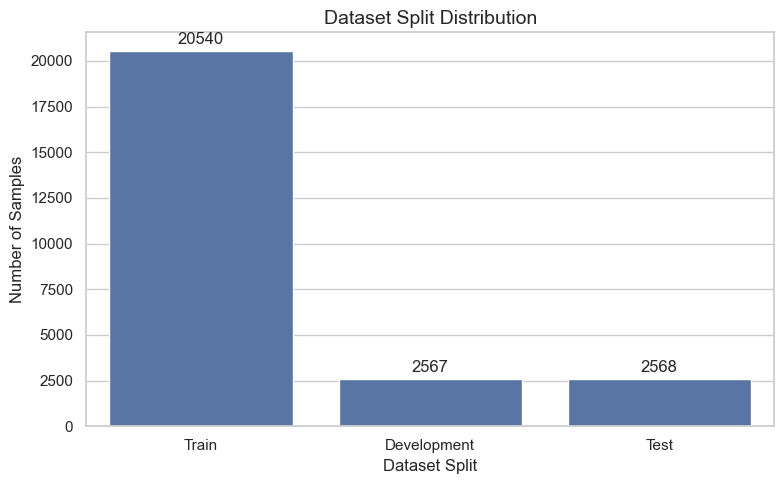

In [44]:
plot_dataset_split_distribution(
    y_train_df,
    y_dev_df,
    y_test_df
)

In [45]:
print(f"X_train First 5 Features:\n")
display(X_train_df.head())

print(f"X_train First 5 Labels:\n")
display(y_train_df.head())

X_train First 5 Features:



,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,...,x17,y17,x18,y18,x19,y19,x20,y20,x21,y21
0,0.0,0.0,0.160702,-0.138841,0.260678,-0.274857,0.303302,-0.404739,0.329285,-0.520484,...,-0.005471,-0.940434,-0.115922,-0.473476,-0.114377,-0.622100,-0.113143,-0.719530,-0.112741,-0.807652
1,0.0,0.0,0.107040,-0.465172,0.386724,-0.912957,0.577065,-1.248251,0.583667,-1.554021,...,1.027991,-0.071935,0.921692,0.065463,1.351488,0.135940,1.609770,0.218833,1.834802,0.273747
2,0.0,0.0,0.096409,-0.121380,0.107819,-0.277830,-0.007652,-0.386379,-0.137193,-0.450946,...,-0.075970,-0.297274,-0.185212,-0.343275,-0.218887,-0.393146,-0.162242,-0.306575,-0.113654,-0.231674
3,0.0,0.0,0.163784,-0.062907,0.309262,-0.167065,0.413606,-0.254932,0.438353,-0.371972,...,0.164832,-1.005639,-0.103920,-0.516224,-0.118518,-0.698894,-0.104176,-0.822057,-0.076067,-0.921018
4,0.0,0.0,0.448118,-0.202196,0.861090,-0.659758,0.942159,-1.144115,0.759553,-1.459370,...,0.098332,-0.891144,-0.299421,-1.124591,-0.183397,-1.299015,-0.119053,-0.983382,-0.161057,-0.908327


X_train First 5 Labels:



0    12
1     0
2     9
3     6
4     2
Name: label, dtype: int64

In [46]:
# convert to numpy array
X_train_np = X_train_df.to_numpy()
y_train_np = y_train_df.to_numpy()

X_dev_np = X_dev_df.to_numpy()
y_dev_np = y_dev_df.to_numpy()

X_test_np = X_test_df.to_numpy()
y_test_np = y_test_df.to_numpy()

## RandomForestClassifier

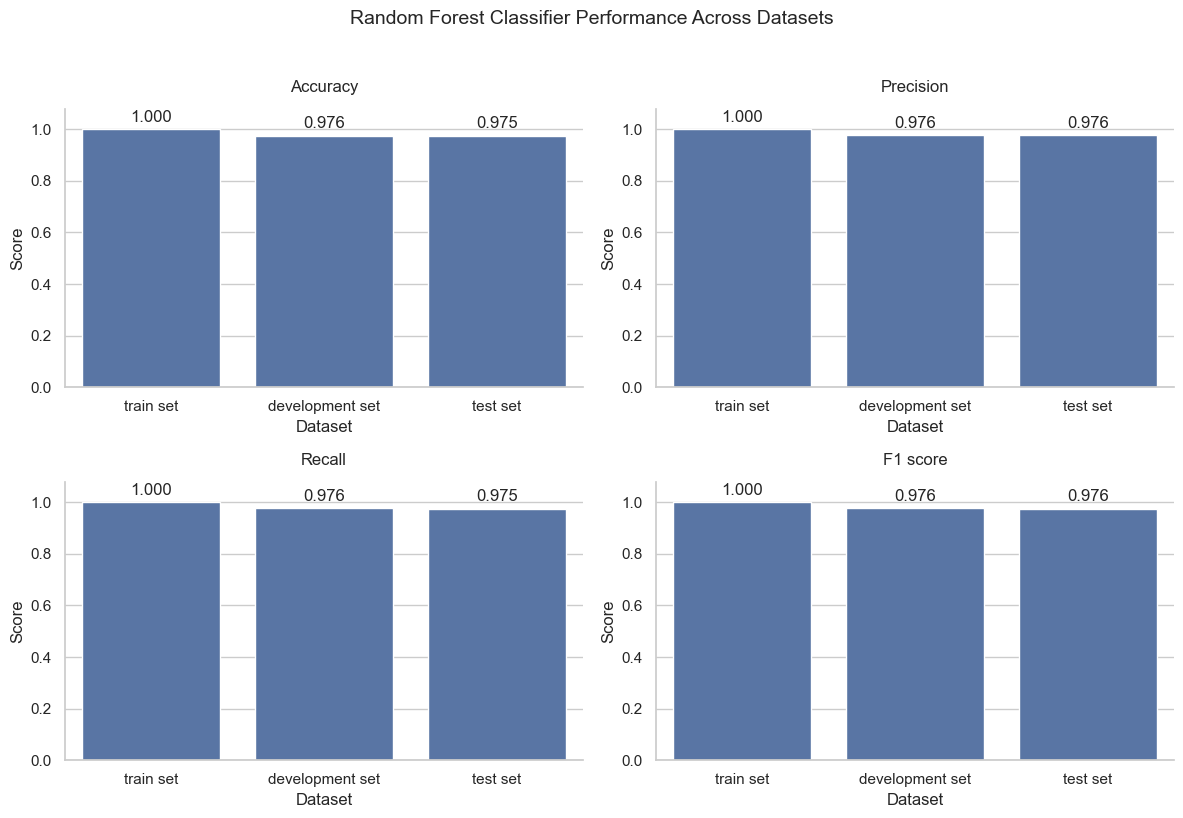

In [47]:
rf_model_name = "Random Forest Classifier"

# initialize RandomForestClassifier object
rf_model = RandomForestClassifier(random_state=0)

# initialize ModelTrainer object
rf_trainer = ModelTrainer(X_train_np, y_train_np)

# train rf_trainer object
rf_trainer.train(rf_model, rf_model_name)

# evaluate rf_model on datasets
rf_trainer.evaluate_and_store(rf_model_name, X_train_np, y_train_np, "train set")
rf_trainer.evaluate_and_store(rf_model_name, X_dev_np, y_dev_np, "development set")
rf_trainer.evaluate_and_store(rf_model_name, X_test_np, y_test_np, "test set")

# display performance metrics
plot_model_performance_subplots(rf_trainer, rf_model_name)

In [48]:
rf_conf_train_fig = rf_trainer.plot_confusion_matrix(rf_model_name, le, "train set")

rf_conf_dev_fig = rf_trainer.plot_confusion_matrix(rf_model_name, le, "development set")

rf_conf_test_fig = rf_trainer.plot_confusion_matrix(rf_model_name, le, "test set")

# display dev set confusion matrix
rf_conf_dev_fig.show()

In [49]:
# get model
rf_clf = rf_trainer.get_model(model_name=rf_model_name)
rf_clf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [50]:
metrics = rf_trainer.results[rf_model_name]["metrics"]["development set"]

rf_corr_pred_fig = plot_correct_landmarks(
    rf_clf,
    X_dev_df,
    y_dev_df,
    le,
    model_name="RandomForest",
    dataset_name="Development",
    accuracy=metrics["accuracy"],
    n_samples=9
)

d:\ITI Materials\Projects\Hand Marks Detection\Hands_Marks_Detection_main\hand_gest_env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



In [51]:
rf_comp_fig  = plot_two_class_table(
    rf_clf,
    X_dev_np,
    y_dev_np,
    le,
    "two_up",
    "peace",
    model_name="RandomForest",
    dataset_name="Development",
    f1_score=metrics["f1_score"],
    n_per_cell=4
)

## SVM

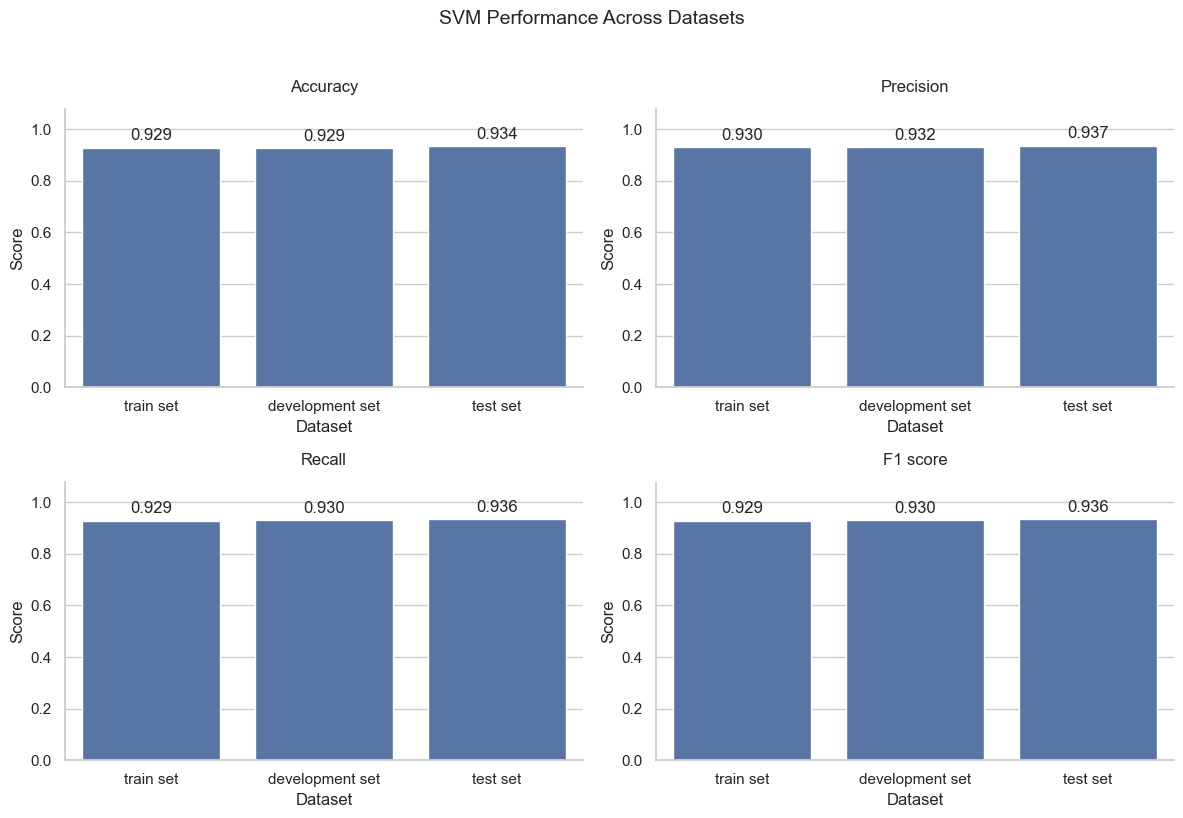

In [52]:
svm_model_name = "SVM"

# initialize SVM object
SVM_model = SVC(kernel='rbf', C=1, gamma='scale', random_state=0)

# initialize ModelTrainer object
SVM_trainer = ModelTrainer(X_train_np, y_train_np)

# train SVM_trainer object
SVM_trainer.train(SVM_model, svm_model_name)

# evaluate SVM_model on datasets
SVM_trainer.evaluate_and_store(svm_model_name, X_train_np, y_train_np, "train set")
SVM_trainer.evaluate_and_store(svm_model_name, X_dev_np, y_dev_np, "development set")
SVM_trainer.evaluate_and_store(svm_model_name, X_test_np, y_test_np, "test set")

# print out the metrics
plot_model_performance_subplots(SVM_trainer, svm_model_name)

In [53]:
svm_conf_train_fig = SVM_trainer.plot_confusion_matrix(svm_model_name, le, "train set")

svm_conf_dev_fig = SVM_trainer.plot_confusion_matrix(svm_model_name, le, "development set")

svm_conf_test_fig = SVM_trainer.plot_confusion_matrix(svm_model_name, le, "test set")

# show dev set confusion matrix
svm_conf_dev_fig.show()

In [54]:
# get svm model
svm_clf = SVM_trainer.get_model(model_name=svm_model_name)
svm_clf

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [55]:
metrics = SVM_trainer.results[svm_model_name]["metrics"]["development set"]

svm_corr_pred_fig = plot_correct_landmarks(
    svm_clf,
    X_dev_df,
    y_dev_df,
    le,
    model_name="SVM",
    dataset_name="Development",
    accuracy=metrics["accuracy"],
    n_samples=9
)

d:\ITI Materials\Projects\Hand Marks Detection\Hands_Marks_Detection_main\hand_gest_env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning:

X has feature names, but SVC was fitted without feature names



In [56]:
svm_comp_fig = plot_two_class_table(
    svm_clf,
    X_dev_np,
    y_dev_np,
    le,
    "two_up",
    "peace",
    model_name="SVM",
    dataset_name="Development",
    f1_score=metrics["f1_score"],
    n_per_cell=4
)

## DecisionTreeClassifier

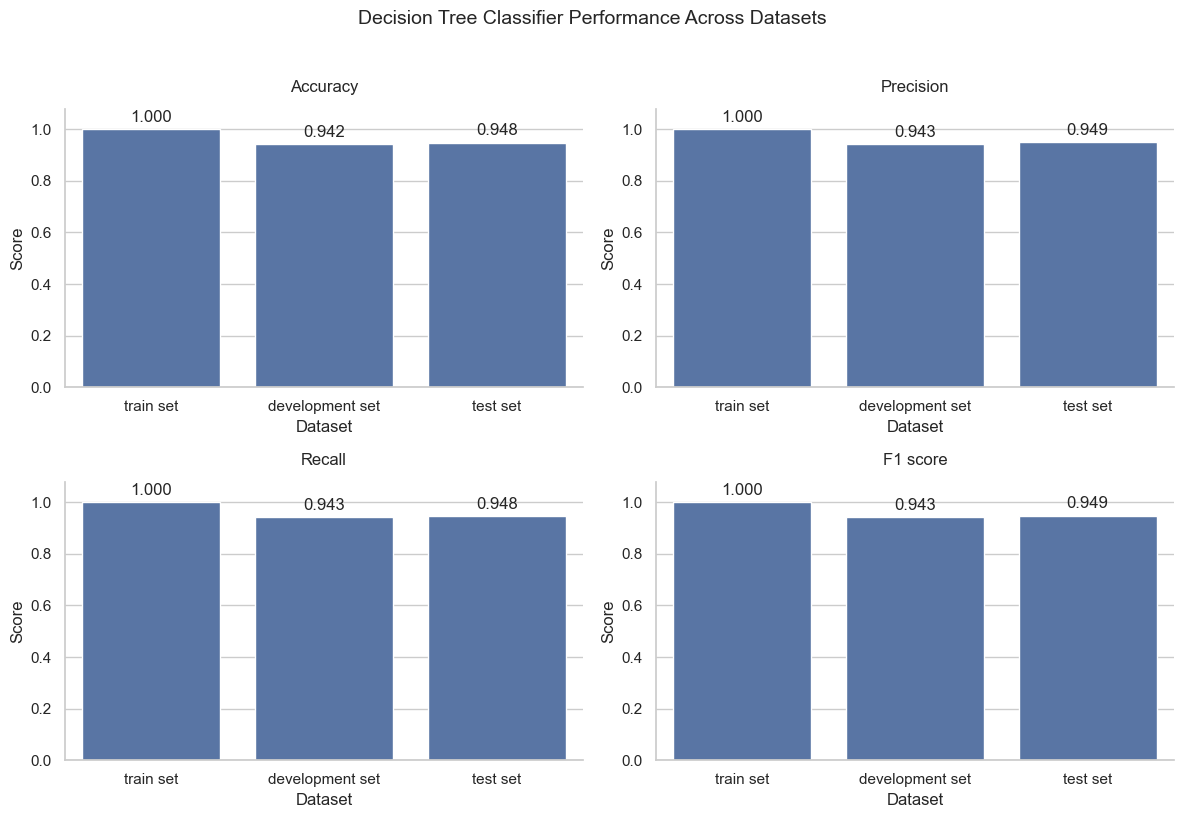

In [57]:
dt_model_name = "Decision Tree Classifier"

# initialize RandomForestClassifier object
dt_model = DecisionTreeClassifier(random_state=0)

# initialize ModelTrainer object
dt_trainer = ModelTrainer(X_train_np, y_train_np)

# train dt_trainer object
dt_trainer.train(dt_model, dt_model_name)

# evaluate dt_model on datasets
dt_trainer.evaluate_and_store(dt_model_name, X_train_np, y_train_np, "train set")
dt_trainer.evaluate_and_store(dt_model_name, X_dev_np, y_dev_np, "development set")
dt_trainer.evaluate_and_store(dt_model_name, X_test_np, y_test_np, "test set")

# print out the metrics
plot_model_performance_subplots(dt_trainer, dt_model_name)

In [58]:
dt_conf_train_fig = dt_trainer.plot_confusion_matrix(dt_model_name, le, "train set")

dt_conf_dev_fig = dt_trainer.plot_confusion_matrix(dt_model_name, le, "development set")

dt_conf_tets_fig = dt_trainer.plot_confusion_matrix(dt_model_name, le, "test set")

# show dev set confusion matrix
dt_conf_dev_fig.show()

In [59]:
# get decision tree model
dt_clf = dt_trainer.get_model(model_name=dt_model_name)
dt_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [60]:
metrics = dt_trainer.results[dt_model_name]["metrics"]["development set"]

dt_corr_pred_fig = plot_correct_landmarks(
    dt_clf,
    X_dev_df,
    y_dev_df,
    le,
    model_name="Decision Tree",
    dataset_name="Development",
    accuracy=metrics["accuracy"],
    n_samples=9
)

d:\ITI Materials\Projects\Hand Marks Detection\Hands_Marks_Detection_main\hand_gest_env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning:

X has feature names, but DecisionTreeClassifier was fitted without feature names



In [61]:
dt_comp_fig = plot_two_class_table(
    dt_clf,
    X_dev_np,
    y_dev_np,
    le,
    "two_up",
    "peace",
    model_name="Decision Tree",
    dataset_name="Development",
    f1_score=metrics["f1_score"],
    n_per_cell=4
)

# 1. Results and Discussion

## 1.1 Experimental Overview

Three classical machine learning models were evaluated for hand gesture classification using landmark coordinate features: Decision Tree, Random Forest, and Support Vector Machine (RBF kernel). The models were trained on 20,540 samples and evaluated on separate development and test sets. Performance was assessed using Accuracy, Precision, Recall, and F1-score.

---

## 1.2 Random Forest Performance

The Random Forest classifier achieved 100% performance across all metrics on the training set. On the development and test sets, it maintained approximately 97% performance across Accuracy, Precision, Recall, and F1-score, resulting in an approximate 2.5% generalization gap.

This limited gap indicates strong generalization capability without significant overfitting or underfitting.

### Error Analysis

Confusion matrix analysis reveals that the majority of "two_up" and "peace" gestures are correctly classified across varying hand rotations and minor differences in finger spread.

Only 4 misclassifications were observed in the development set.

Misclassifications primarily occurred in the following scenarios:

- Slight increase in the angle between index and middle fingers, causing "two_up" gestures to resemble "peace".
- Hand orientations angled toward or away from the camera, where the 3D "V" shape appears more parallel in 2D projection.
- Reduced performance on inverted "peace" gestures (~93% class accuracy).

Overall, Random Forest demonstrates robustness to natural human variability and geometric ambiguity.

---

## 1.3 Support Vector Machine (RBF Kernel)

The SVM required the longest training time (approximately 1 minute). While its training performance was lower than Random Forest, its test performance was slightly higher than its development performance. This pattern suggests the absence of overfitting and indicates stable generalization.

Precision and Recall values differed by less than 0.01, demonstrating balanced treatment of false positives and false negatives and no observable class bias.

### Error Characteristics

The SVM produced 27 misclassifications between the "peace" and "two_up" gestures. These errors were symmetric, reflecting geometric ambiguity rather than systematic bias.

Visual inspection of prediction quadrants revealed:

- Confusion in tilted hand configurations (~45° rotations).
- In the True two_up / Pred peace region, skeletal landmarks closely resemble genuine "peace" configurations.
- In the True peace / Pred two_up region, reduced finger spread shifts feature representations toward the two_up cluster.

The RBF kernel operates by measuring proximity to support vectors. When finger spread is insufficient, the feature embedding moves closer to the alternative gesture cluster, leading to misclassification.

Although slightly less accurate than Random Forest, SVM demonstrates consistent geometric pattern learning and stable generalization.

---

## 1.4 Decision Tree Performance

The Decision Tree achieved 100% performance across all training metrics. However, it exhibited an approximate 6% performance drop on the test set, indicating overfitting.

The primary cause appears to be excessive tree depth, leading to highly specific leaf nodes that memorize exact landmark configurations. Such overly complex decision boundaries lack smooth generalization.

In practical scenarios, minor variations in hand orientation, distance, or landmark positioning degrade performance due to the model’s reliance on memorized coordinate patterns rather than learned geometric relationships.

Limiting the maximum depth did not significantly reduce the generalization gap.

---

## 1.5 Comparative Analysis

| Model            | Training Performance | Test Performance | Generalization Behavior |
|------------------|---------------------|------------------|--------------------------|
| Decision Tree   | 100%                | ~94%             | Overfitting              |
| Random Forest   | 100%                | ~97.4%           | Strong generalization    |
| SVM (RBF)       | Lower than RF       | Stable (~4–5% below RF) | Most stable pattern |

Key observations:

- Decision Tree is the fastest model (19 seconds) but exhibits clear overfitting.
- Random Forest achieves the highest overall performance (~97.4%) with minimal generalization gap.
- SVM demonstrates the most stable generalization behavior and balanced class treatment.

Random Forest handles the geometric ambiguity between "peace" and "two_up" gestures more effectively than the other models. It is robust to rotation, finger spread variation, and minor landmark noise, while remaining computationally efficient on CPU.

SVM remains a viable secondary candidate due to its stable learning of geometric relationships, particularly in scenarios where streaming or unseen environments may challenge ensemble methods.

---

## 1.6 Final Model Selection

Based on quantitative performance, error analysis, robustness to geometric variation, and computational efficiency, the Random Forest classifier is selected as the primary deployment model.

It provides the best trade-off between:

- Accuracy  
- Stability  
- Robustness to natural variation  
- Computational efficiency  

For real-world deployment and live inference scenarios, Random Forest offers the most reliable and balanced performance.

## Save models

In [62]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from helpers import preprocess_landmarks

# preprocessing function
preprocess_transformer = FunctionTransformer(preprocess_landmarks)

# Create pipeline
rf_pipeline = Pipeline([
    ("preprocess", preprocess_transformer),
    ("model", rf_clf)
])

# Save pipeline
models_dir = "../models"
joblib.dump(rf_pipeline, f"{models_dir}/random_forest_pipeline.pkl")

['../models/random_forest_pipeline.pkl']